# **Bank Churn Analysis**

Dataset Source <br>
https://www.kaggle.com/datasets/saurabhbadole/bank-customer-churn-prediction-dataset

**RowNumber**: The sequential number assigned to each row in the dataset.

**CustomerId**: A unique identifier for each customer.

**Surname**: The surname of the customer.

**CreditScore**: The credit score of the customer.

**Geography**: The geographical location of the customer (e.g., country or region).

**Gender**: The gender of the customer.

**Age**: The age of the customer.

**Tenure**: The number of years the customer has been with the bank.

**Balance**: The account balance of the customer.

**NumOfProducts**: The number of bank products the customer has.

**HasCrCard**: Indicates whether the customer has a credit card (binary: yes/no).

**IsActiveMember**: Indicates whether the customer is an active member (binary: yes/no).

**EstimatedSalary**: The estimated salary of the customer.

**Exited**: Indicates whether the customer has exited the bank (binary: yes/no).

---

### **Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_theme(
    style="whitegrid",
    font="sans-serif",
    rc={
        "figure.figsize": (8, 5),
        "axes.edgecolor": "#EAEAEA",
        "grid.color": "#686D76",
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11
    }
)

In [2]:
df = pd.read_csv('../data/bank_customer_churn.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print('== Dataset Profile ==')
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]} \n')

print('== Missing Values ==')
missing_count = df.isna().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    'Total': missing_count,
    'Percentage(%)': missing_pct
})
missing_summary = missing_summary[missing_summary['Total'] > 0].sort_values(by='Total', ascending=False)
print(missing_summary if not missing_summary.empty else 'No missing values found', '\n')

print('== Duplicate Data ==')
print(f'Total Duplicates : {df.duplicated().sum()}\nDuplicate Percentage : {(df.duplicated().sum()/len(df)*100).round(2)}\n')

print('== Column Data Types ==')
print(df.dtypes)

== Dataset Profile ==
Baris: 10000
Kolom: 14 

== Missing Values ==
No missing values found 

== Duplicate Data ==
Total Duplicates : 0
Duplicate Percentage : 0.0

== Column Data Types ==
RowNumber            int64
CustomerId           int64
Surname                str
CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


---
### **Data Cleaning**

In [4]:
# Drop kolom yang tidak relevan
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print(f'Kolom tersisa: {df.columns.tolist()}\n')
print(f'Baris: {df.shape[0]}\nKolom: {df.shape[1]}')

Kolom tersisa: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Baris: 10000
Kolom: 11


---
### **Exploratory Data Analysis**

**Distribusi Target**

         Status  Count
0  Retained (0)   7963
1   Churned (1)   2037


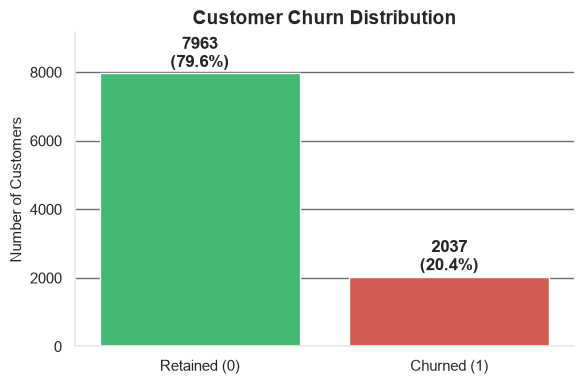

In [5]:
# == Distribusi Target == 
fig, ax = plt.subplots(figsize=(6, 4))

churn_counts = df['Exited'].value_counts().reset_index()
churn_counts.columns = ['Status', 'Count']
churn_counts['Status'] = churn_counts['Status'].map({0: 'Retained (0)', 1: 'Churned (1)'})

print(churn_counts)

sns.barplot(
    data=churn_counts,
    x='Status',
    y='Count',
    hue='Status',
    palette=['#2ecc71', '#e74c3c'],
    ax=ax
)

for bar, (_, row) in zip(ax.patches, churn_counts.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{int(row['Count'])}\n({row['Count']/len(df)*100:.1f}%)",
            ha='center', va='bottom', fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
ax.set_xlabel('')
ax.set_ylim(0, churn_counts['Count'].max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig('../assets/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

==========================================================================

Churn Rate 20.4%, dengan total 2037 dari 10000. Data sangat Imbalanced.

==========================================================================

**Distribusi Fitur Numerik Berdasarkan Target**

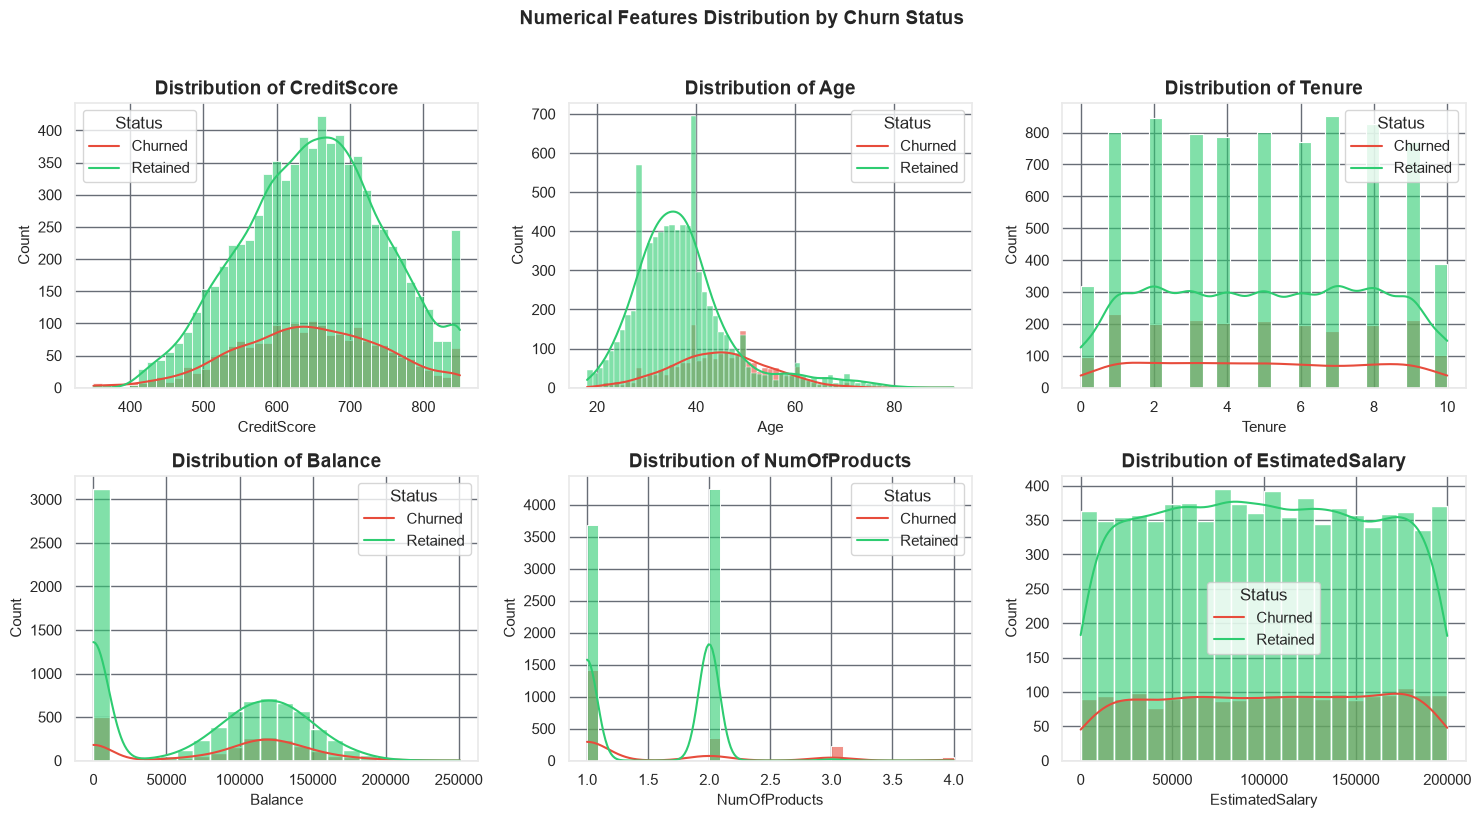

In [6]:
# == Distribusi Fitur Numerik berdasarkan Target ==
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(
        data=df, 
        x=col, 
        hue='Exited', 
        kde=True,
        palette={0: '#2ecc71', 1: '#e74c3c'},
        alpha=0.6, 
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['Churned', 'Retained'], title='Status')

plt.suptitle('Numerical Features Distribution by Churn Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../assets/02_numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

==========================================================================

**CreditScore**: Bentuk distribusi kedua nilai identik dengan peak di 600-700.

**Age**: churned customers cenderung umur pertengahan dan peak di sekitar 40-50

**Tenure**: Bentuk distribusi identik antara kedua nilai, lamanya tenure tidak mempengaruhi kecenderungan churn.

**Balance**: Banyak customer yang retain dengan balance 0, sedangkan churn lebih terkonsentrasi di balance range 100k-150k. Customer dengan balance menengah lebih beresiko churn.

**NumOfProducts**: Perbedaan terbesar antara retained dan churned customer terdapat pada product nomor 2, dengan jumlah retained lebih banyak. Sedangkan churned customer lebih berpusat pada produk nomor 1. Perlu dicatat, produk nomor 3 dan 4 volumenya sangat kecil, tetapi hampir semua customer itu churn.

**EstimatedSalary**: Distribusi kedua nilai cenderung flat di semua range salary, dapat diartikan bukan faktor penentu customer churn atau tidak.

==========================================================================

In [7]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**Distribusi Fitur Kategorikal Berdasarkan Target**

,Geography,ChurnRate
0,France,16.154767
1,Germany,32.443204
2,Spain,16.673395


,Gender,ChurnRate
0,Female,25.071539
1,Male,16.455928


,NumOfProducts,ChurnRate
0,1,27.714398
1,2,7.581699
2,3,82.706767
3,4,100.000000


,HasCrCard,ChurnRate
0,0,20.814941
1,1,20.184266


,IsActiveMember,ChurnRate
0,0,26.850897
1,1,14.269074


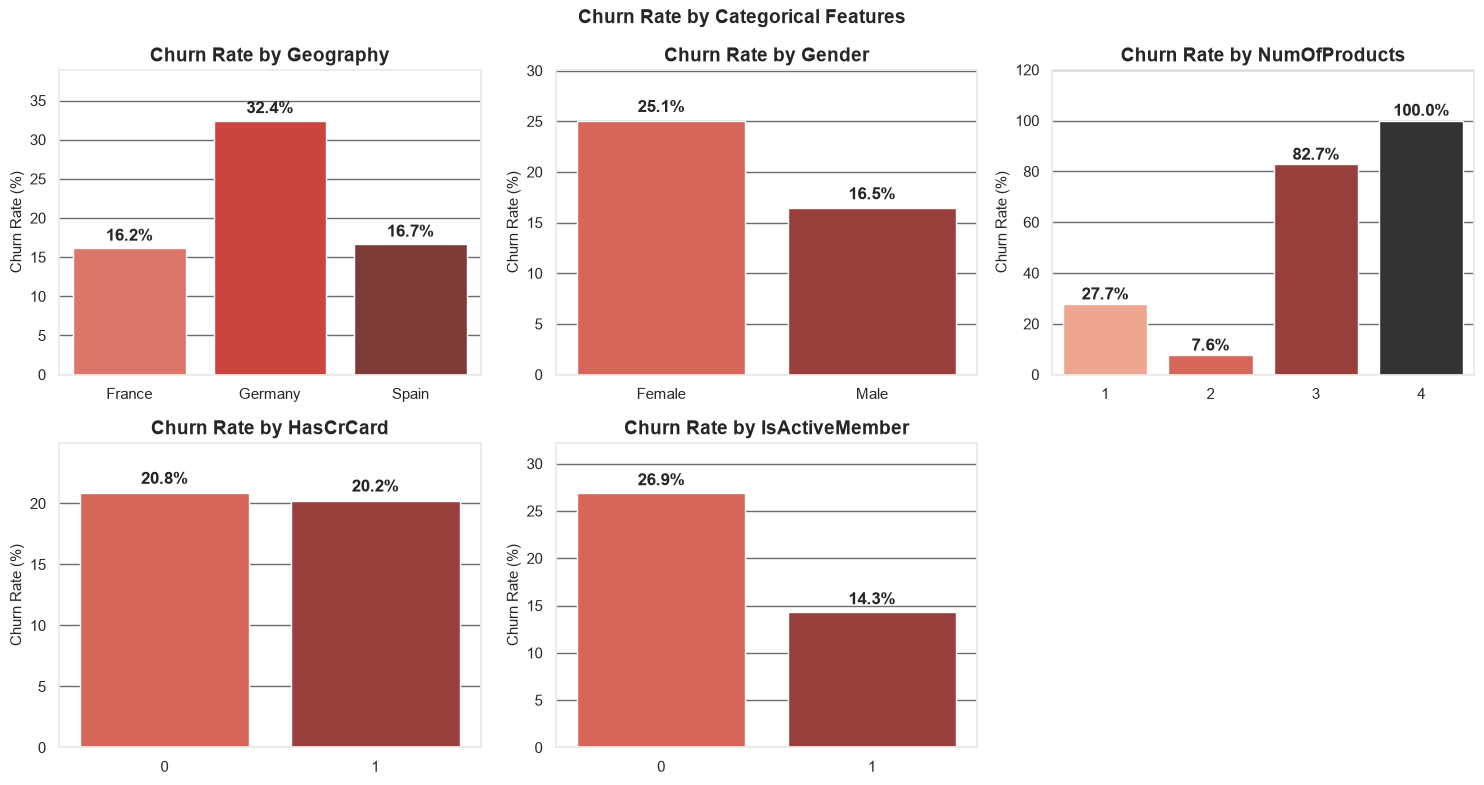

In [8]:
# == Distribusi Fitur Kategorikal Berdasarkan Target ==
categorical_cols = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    churn_rate = df.groupby(col)['Exited'].mean().reset_index()
    churn_rate.columns = [col, 'ChurnRate']
    churn_rate['ChurnRate'] = churn_rate['ChurnRate'] * 100

    display(churn_rate)

    sns.barplot(
        data=churn_rate, 
        x=col, 
        y='ChurnRate',
        hue=col,
        palette='Reds_d',
        ax=axes[i],
        legend=False
    )
    
    for bar, rate in zip(axes[i].patches, churn_rate['ChurnRate']):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')

    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, churn_rate['ChurnRate'].max() * 1.2)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/03_churn_by_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

==========================================================================

**Geography**: Germany memiliki churn rate tertinggi di 32.4%, lebih tinggi sekitar 2x lipat dari Spain dan France.

**Gender**: Female lebih tinggi 9%-10% dari Male. Female lebih beresiko churn.

**NumOfProducts**: 2 produk paling aman dengan chance customer churn di 7.6%, kedua ada 1 produk yang lebih tinggi tetapi cenderung rendah di 27.7%. 3 & 4 produk memiliki churn rate sangat tinggi di 82.7% dan 100%, sangat beresiko atau bahkan dipastikan churn.

**HasCrCard**: Kedua nilai hampir tidak ada perbedaan, dapat dikatakan kepemilikan credit card tidak mempengaruhi tingkat churn.

**IsActiveMember**: Customer yang tidak aktif member lebih beresiko churn (26.9%) dibanding yang aktif menjadi member (14.3%).

==========================================================================

**Top Features:**
1. NumOfProducts
2. Age
3. Geography
4. IsActiveMember
5. Gender
6. Balance

==========================================================================

**Correlation Heatmap**

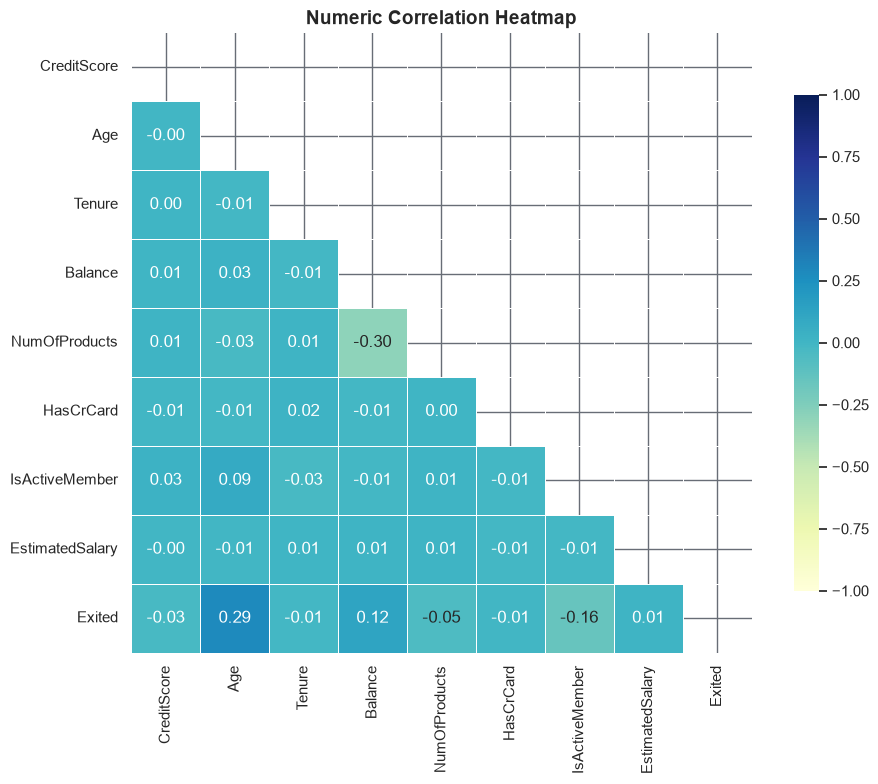

In [9]:
# Correlation Heatmap

fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    center=0, 
    vmin=-1, 
    vmax=1,
    square=True, 
    linewidths=0.5, 
    ax=ax,
    cbar_kws={'shrink': 0.8})

ax.set_title('Numeric Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

==========================================================================

== Korelasi Fitur Numeric Terhadap Target (Exited) ==
- Age (0.29): Korelasi positif dengan target terkuat. Semakin tua makin berisiko churn.
- Balance (0.12): Korelasi positif lemah. Semakin banyak saldo, sedikit meningkatkan risiko churn.
- IsActiveMember (-0.16): Korelasi negatif. Semakin aktif member, risiko churn berkurang.

== Korelasi Antar Fitur Numeric (multicollinearity) ==
- NumOfProducts <-> Balance (-0.30)
- Sebagian besar pair mendekati 0, tidak ada multicollinearity

==========================================================================

**Outlier/Boxplot**

In [10]:
display(df.describe())

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


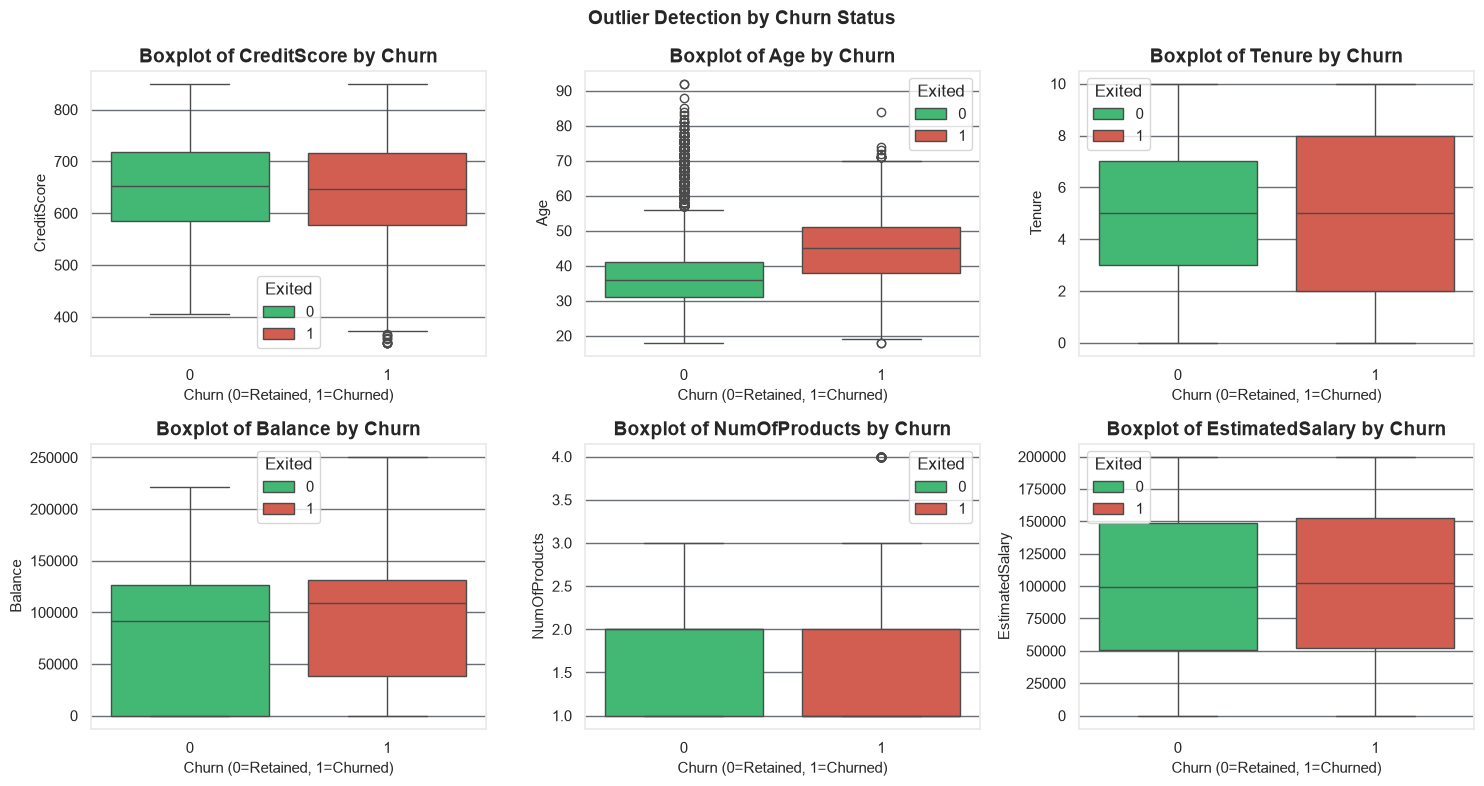

In [11]:
# Outlier Check

numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(
        data=df, 
        x='Exited', 
        y=col,
        hue='Exited',
        palette={0: '#2ecc71', 1: '#e74c3c'},
        ax=axes[i]
    )
    axes[i].set_title(f'Boxplot of {col} by Churn', fontweight='bold')
    axes[i].set_xlabel('Churn (0=Retained, 1=Churned)')
    axes[i].set_ylabel(col)

plt.suptitle('Outlier Detection by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/05_boxplot_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

==========================================================================

- **CreditScore**: Ada sedikit outlier dibawah 350an pada Churn.
- **Age**: Banyak outlier diatas umur 70-90 pada kedua nilai. Wajar untuk data customer perbankan.
- **NumOfProducts**: Ada 1 nilai extreme di 4 pada Churn.

==========================================================================

---
### **Preprocessing**

In [12]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
# Data Split

from sklearn.model_selection import train_test_split

X = df.drop(columns=['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8000, 10)
Test size: (2000, 10)


In [14]:
# One-Hot Encoding

X_train = pd.get_dummies(X_train, columns=['Geography', 'Gender'], dtype=int, drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Geography', 'Gender'], dtype=int, drop_first=True)

In [15]:
# Handle Imbalance Data (SMOTE)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:", y_train.value_counts().to_dict())
print("Setelah SMOTE:", y_train_sm.value_counts().to_dict())

Sebelum SMOTE: {0: 6370, 1: 1630}
Setelah SMOTE: {1: 6370, 0: 6370}


In [16]:
# Standar Scaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing selesai!")
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

Preprocessing selesai!
X_train shape: (12740, 11)
X_test shape: (2000, 11)


---
### **Modeling**

**Random Forest**

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train_sm)

y_pred_rf = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", round(roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1]), 4))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.91      0.86      0.88      1593
           1       0.54      0.65      0.59       407

    accuracy                           0.82      2000
   macro avg       0.72      0.75      0.74      2000
weighted avg       0.83      0.82      0.82      2000

ROC-AUC: 0.8389


**Kesimpulan:**<br>
Model RandomForest hanya dapat memprediksi 65% customer yang churn (dilihat dari score recall kelas 1).

**XGBoost**

In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_scaled, y_train_sm)

y_pred_xgb = xgb.predict(X_test_scaled)

print("=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb.predict_proba(X_test_scaled)[:, 1]), 4))

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      1593
           1       0.51      0.63      0.56       407

    accuracy                           0.80      2000
   macro avg       0.71      0.74      0.72      2000
weighted avg       0.82      0.80      0.81      2000

ROC-AUC: 0.8262


**Kesimpulan:**<br>
Model XGBoost hanya dapat memprediksi 63% customer yang churn (dilihat dari score recall kelas 1).

---
### **Hyperparameter Tuning**

**Tuning RandomForest**

In [19]:
import optuna
from sklearn.metrics import recall_score
from tqdm.notebook import tqdm

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [20]:
# # Tuning RandomForest
# def objective_rf(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 600),
#         'max_depth': trial.suggest_int('max_depth', 3, 20),
#         'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
#         'random_state': 42
#     }
#     model = RandomForestClassifier(**params)
#     model.fit(X_train_scaled, y_train_sm)
#     y_pred = model.predict(X_test_scaled)
#     return recall_score(y_test, y_pred, pos_label=1)

# study_rf = optuna.create_study(direction='maximize')

# with tqdm(total=100, desc="Tuning Random Forest") as pbar:
#     def callback(study, trial):
#         pbar.update(1)
#     study_rf.optimize(objective_rf, n_trials=100, callbacks=[callback])

# print("Best RF params:", study_rf.best_params)
# print("Best RF Recall:", round(study_rf.best_value, 4))

Best RF Params:
- n_estimators: 383
- max_depth: 14
- min_samples_split: 4
- min_samples_leaf: 1

**Tuning XGBoost**

In [21]:
# # Tuning XGBoost
# def objective_xgb(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 600),
#         'max_depth': trial.suggest_int('max_depth', 3, 12),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'gamma': trial.suggest_float('gamma', 0.0, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
#         'random_state': 42,
#         'eval_metric': 'logloss'
#     }
#     model = XGBClassifier(**params)
#     model.fit(X_train_scaled, y_train_sm)
#     y_pred = model.predict(X_test_scaled)
#     return recall_score(y_test, y_pred, pos_label=1)

# study_xgb = optuna.create_study(direction='maximize')

# with tqdm(total=100, desc="Tuning XGBoost") as pbar:
#     def callback(study, trial):
#         pbar.update(1)
#     study_xgb.optimize(objective_xgb, n_trials=100, callbacks=[callback])

# print("Best XGBoost params:", study_xgb.best_params)
# print("Best XGBoost Recall:", round(study_xgb.best_value, 4))

In [22]:
# import json

# # Save best params
# best_params = {
#     'rf': study_rf.best_params,
#     'xgb': study_xgb.best_params
# }

# with open('../assets/best_params.json', 'w') as f:
#     json.dump(best_params, f, indent=4)

# print("Best params saved!")
# print(json.dumps(best_params, indent=4))

In [23]:
import json

with open('../assets/best_params.json', 'r') as f:
    best_params = json.load(f)

rf_best = best_params['rf']
xgb_best = best_params['xgb']

print("Params loaded!")
print(rf_best)
print(xgb_best)

Params loaded!
{'n_estimators': 331, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
{'n_estimators': 501, 'max_depth': 3, 'learning_rate': 0.02279739799502843, 'subsample': 0.6178231432768746, 'colsample_bytree': 0.6087982861261753, 'min_child_weight': 1, 'gamma': 0.004316490558686992, 'reg_alpha': 0.845373174139799, 'reg_lambda': 1.695113612577754}


**Re-Train Models**

In [24]:
# RandomForest Tuned
rf_tuned = RandomForestClassifier(**rf_best)
rf_tuned.fit(X_train_scaled, y_train_sm)
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)

print("=== Random Forest Tuned ===")
print(classification_report(y_test, y_pred_rf_tuned))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_tuned.predict_proba(X_test_scaled)[:, 1]), 4))

=== Random Forest Tuned ===
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      1593
           1       0.51      0.67      0.58       407

    accuracy                           0.80      2000
   macro avg       0.71      0.75      0.73      2000
weighted avg       0.83      0.80      0.81      2000

ROC-AUC: 0.8414


In [25]:
# XGBoost Tuned
xgb_tuned = XGBClassifier(**xgb_best)
xgb_tuned.fit(X_train_scaled, y_train_sm)
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)

print("\n=== XGBoost Tuned ===")
print(classification_report(y_test, y_pred_xgb_tuned))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_tuned.predict_proba(X_test_scaled)[:, 1]), 4))


=== XGBoost Tuned ===
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1593
           1       0.51      0.70      0.59       407

    accuracy                           0.80      2000
   macro avg       0.71      0.76      0.73      2000
weighted avg       0.83      0.80      0.81      2000

ROC-AUC: 0.8487


**Kesimpulan:**
- XGBoost Tuned menjadi yang terbaik di Recall, naik dari 63% ke 70%.
- XGBoost Tuned menjadi model terbaik untuk di deploy.

---
### **Evaluasi**

**Confusion Matrix**

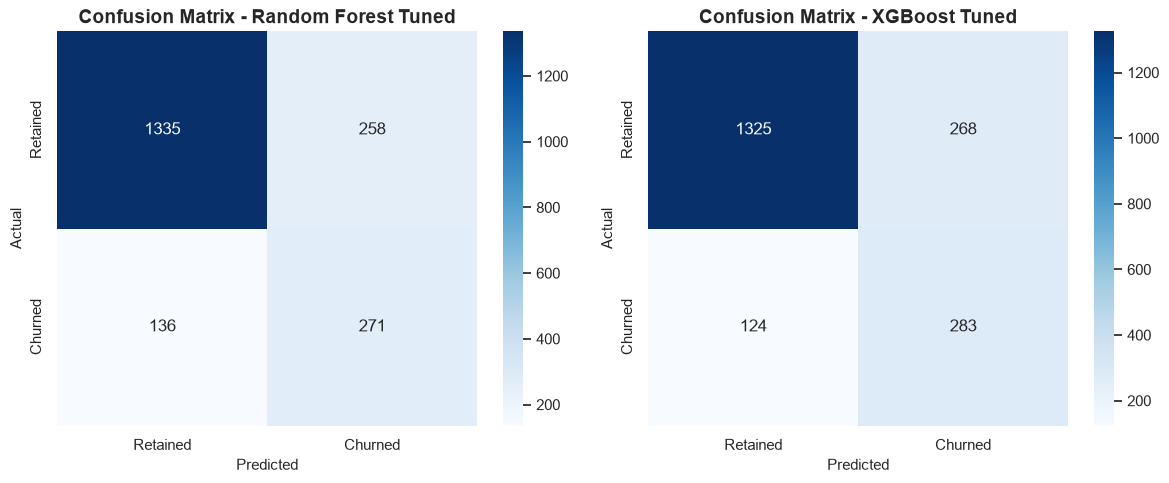

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = {
    'Random Forest Tuned': y_pred_rf_tuned,
    'XGBoost Tuned': y_pred_xgb_tuned
}

for ax, (name, y_pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Retained', 'Churned'],
                yticklabels=['Retained', 'Churned'],
                ax=ax)
    ax.set_title(f'Confusion Matrix - {name}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../assets/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Kesimpulan:**<br>
XGBoost Tuned lebih baik. False Negative lebih sedikit dan True Positive lebih banyak terdeteksi.

**Feature Importance**

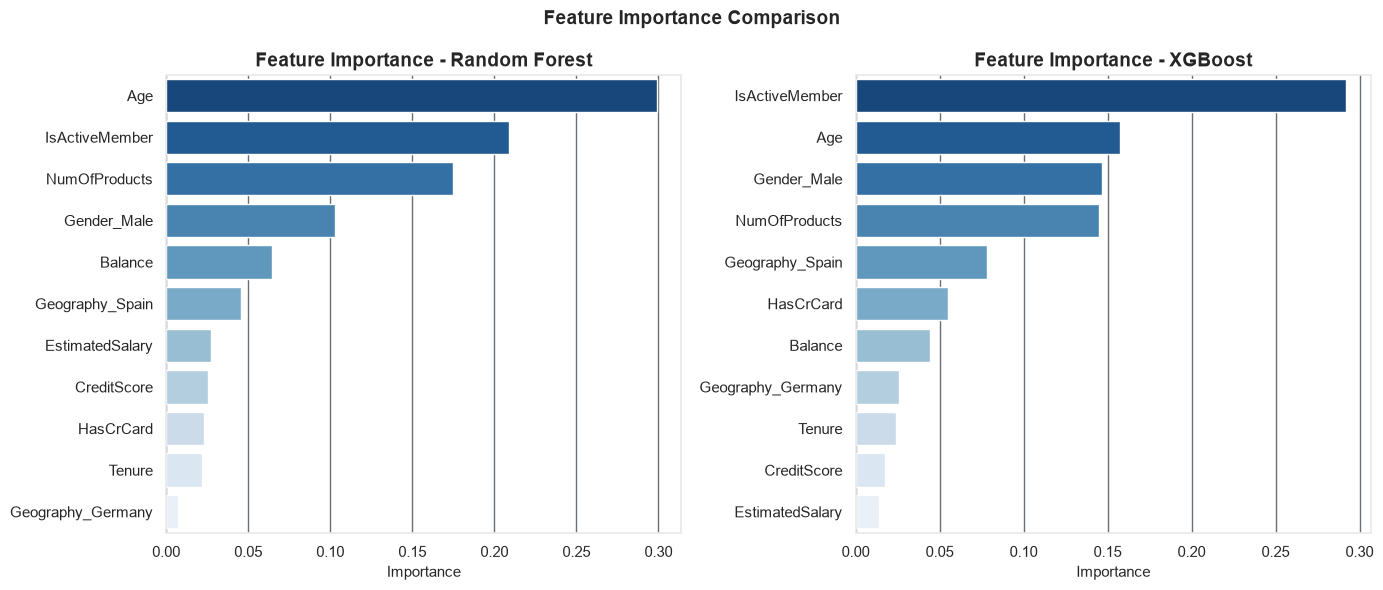

In [27]:
feature_names = X_train.columns.tolist()

# Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

# XGBoost
xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=rf_importance, 
    x='Importance', 
    y='Feature',
    hue='Feature', 
    palette='Blues_r', 
    legend=False, 
    ax=axes[0])
axes[0].set_title('Feature Importance - Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('')

sns.barplot(
    data=xgb_importance, 
    x='Importance', 
    y='Feature',
    hue='Feature', 
    palette='Blues_r', 
    legend=False, 
    ax=axes[1])
axes[1].set_title('Feature Importance - XGBoost', fontweight='bold')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Perbandingan Kedua Model:**
- Kedua model sepakat Age, IsActiveMember, NumOfProducts, Gender_Male adalah fitur penting.
- RF lebih menekankan Age, XGBoost lebih menekankan IsActiveMember

---
### **Save Model**

In [28]:
import joblib

joblib.dump(xgb_tuned, '../assets/xgb_model.pkl')
joblib.dump(scaler, '../assets/scaler.pkl')

print("Model saved!")

Model saved!
